# Solución de clustering mensual de libros — Biblioteca Tiozihuatl

## 1. Comprensión del negocio (CRISP-DM)

**Solución:** segmentación no supervisada de libros.  
**Unidad de análisis:** un libro (`libro_id`) observado durante tres meses completos: octubre (`mes_3`), noviembre (`mes_2`) y diciembre de 2025 (`mes_1`).  
**Contexto y necesidad:** la biblioteca reúne actividad de lectura digital y préstamos físicos, pero necesita convertir esos registros en perfiles operativos que faciliten presentar y gestionar el catálogo en la página web.  
**Objetivo analítico:** agrupar los 135 libros por semejanza de uso digital, profundidad de lectura y circulación física.  
**Usuario del resultado:** personal bibliotecario y backend del sistema Tiozihuatl; el estudiante recibe nombres y acciones comprensibles, no números de clúster.  
**Decisión apoyada:** qué tratamiento dar a cada segmento: conservar disponibilidad física, reforzar visibilidad digital o priorizar libros de uso integral.  
**Beneficio esperado:** organizar el catálogo con una regla reproducible basada en comportamiento real.  
**Riesgo:** una asignación incorrecta podría restar visibilidad a un libro o sugerir una acción de disponibilidad inadecuada. El grupo no debe sustituir criterios académicos o temáticos.  
**Criterio de utilidad:** grupos diferenciados por métricas internas, interpretables mediante valores concretos y utilizables por `predict()` en el backend.

`libro_id` y `titulo` identifican resultados, pero no participan en las distancias.

## 2. Comprensión de los datos (CRISP-DM)

### 2.1 Origen, transformación y diccionario

El CSV es la salida del proceso de extracción y agregación de la base `bd_tiozi`; esta libreta no contiene credenciales ni se conecta directamente a producción.

Esquema lógico utilizado:

`libros (1) → (N) interacciones_libros` para actividad digital  
`libros (1) → (N) detalles_prestamo → (1) prestamos` para circulación física

Las interacciones y préstamos se agrupan por `libro_id` entre el 1 de octubre y el 31 de diciembre de 2025. Los libros sin actividad en una medida conservan cero, evitando excluirlos silenciosamente.

#### Diccionario del dataset

| Variable | Significado | Uso |
|---|---|---|
| `libro_id` | Identificador único del libro | Identificación |
| `titulo` | Título del libro | Interpretación |
| `sesiones_mes_3`, `sesiones_mes_2`, `sesiones_mes_1` | Sesiones digitales por mes | K-Means |
| `usuarios_unicos_3m` | Lectores distintos en la ventana | K-Means |
| `promedio_tiempo_segundos_3m` | Duración promedio de lectura | K-Means |
| `porcentaje_promedio_avance_3m` | Avance promedio | K-Means |
| `prestamos_mes_3`, `prestamos_mes_2`, `prestamos_mes_1` | Préstamos físicos por mes | K-Means |
| `tendencia_sesiones` | Cambio digital reciente ajustado por volumen | K-Means |
| `tendencia_prestamos` | Cambio físico reciente ajustado por volumen | K-Means |

Los totales trimestrales y las fechas de periodo se omitieron para evitar redundancia. Las tendencias representan dirección temporal y su correlación se revisa en el EDA.

**Limitaciones iniciales:** solo hay una ventana de tres meses y 135 libros; los ceros pueden significar ausencia real de actividad; el catálogo y la demanda pueden cambiar. No se usan variables posteriores al 31 de diciembre de 2025 para construir esta ventana, por lo que no existe fuga desde meses futuros.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

### 2.2 Carga reproducible del dataset

In [2]:
def localizar_dataset(nombre):
    candidatos = [
        Path(nombre),
        Path('data_mining') / 'datasets' / nombre,
        Path('datasets') / nombre,
        Path('datos') / nombre,
        Path('..') / 'datasets' / nombre,
    ]
    return next((ruta for ruta in candidatos if ruta.exists()), None)

RUTA_DATASET = localizar_dataset('clustering_libros_biblioteca_mensual.csv')
if RUTA_DATASET is None:
    raise FileNotFoundError('No se encontró el CSV mensual de 13 columnas')

df = pd.read_csv(RUTA_DATASET, encoding='utf-8-sig')
print('Archivo:', RUTA_DATASET)
print('Dimensiones:', df.shape)
df.head()

Archivo: data_mining/datasets/clustering_libros_biblioteca_mensual.csv
Dimensiones: (135, 13)


,libro_id,titulo,sesiones_mes_3,sesiones_mes_2,sesiones_mes_1,usuarios_unicos_3m,promedio_tiempo_segundos_3m,porcentaje_promedio_avance_3m,prestamos_mes_3,prestamos_mes_2,prestamos_mes_1,tendencia_sesiones,tendencia_prestamos
0,53,Transition to General Practice Nursing Ingles,0,1,0,1,1465.000,13.920,3,4,6,0.000,0.231
1,54,Manual de Procedimentos Básicos de Enfermería,4,3,2,8,2565.780,46.280,42,70,43,-0.222,0.006
2,55,Anatomía General Portugués,5,11,6,15,4257.500,46.420,4,4,1,0.045,-0.333
3,56,Anatomía Aplicada para Estudiantes de Odontología,2,3,4,7,3891.890,43.700,56,58,56,0.222,0.000
4,57,Manual de técnicas y procedimientos de enfermería,0,0,1,1,8775.000,73.660,4,5,4,1.000,0.000


### 2.3 Control de calidad

Antes de visualizar o entrenar se verifica que el archivo tenga exactamente el esquema esperado, una fila por libro, valores numéricos completos y rangos válidos.

In [3]:
IDENTIFICADORES = ['libro_id', 'titulo']
VARIABLES_X = [
    'sesiones_mes_3',
    'sesiones_mes_2',
    'sesiones_mes_1',
    'usuarios_unicos_3m',
    'promedio_tiempo_segundos_3m',
    'porcentaje_promedio_avance_3m',
    'prestamos_mes_3',
    'prestamos_mes_2',
    'prestamos_mes_1',
    'tendencia_sesiones',
    'tendencia_prestamos',
]
VARIABLES_NO_NEGATIVAS = [v for v in VARIABLES_X if not v.startswith('tendencia_')]
COLUMNAS_ESPERADAS = IDENTIFICADORES + VARIABLES_X

assert list(df.columns) == COLUMNAS_ESPERADAS, 'El orden o nombre de las columnas no coincide'
assert not df['libro_id'].duplicated().any(), 'Existen libro_id duplicados'
assert not df[VARIABLES_X].isna().any().any(), 'Existen valores nulos en variables del modelo'
assert (df[VARIABLES_NO_NEGATIVAS] >= 0).all().all(), 'Existen cantidades negativas'
assert df['porcentaje_promedio_avance_3m'].between(0, 100).all(), 'Avance fuera de 0-100'
assert df[['tendencia_sesiones', 'tendencia_prestamos']].apply(
    lambda s: s.between(-1, 1).all()
).all(), 'Tendencias fuera de -1 a 1'

pd.DataFrame({
    'filas': [len(df)],
    'columnas': [df.shape[1]],
    'libros_unicos': [df['libro_id'].nunique()],
    'duplicados': [int(df['libro_id'].duplicated().sum())],
    'valores_nulos': [int(df.isna().sum().sum())],
})

,filas,columnas,libros_unicos,duplicados,valores_nulos
0,135,13,135,0,0


In [4]:
# Tipos de datos y completitud por columna
calidad_columnas = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'unicos': df.nunique(),
})
calidad_columnas

,tipo,nulos,unicos
libro_id,int64,0,135
titulo,str,0,135
sesiones_mes_3,int64,0,6
sesiones_mes_2,int64,0,10
sesiones_mes_1,int64,0,7
usuarios_unicos_3m,int64,0,13
promedio_tiempo_segundos_3m,float64,0,100
porcentaje_promedio_avance_3m,float64,0,98
prestamos_mes_3,int64,0,39
prestamos_mes_2,int64,0,45


### 2.4 Análisis exploratorio

El EDA permite conocer escalas, concentración de ceros, asimetrías, valores extremos, cambios mensuales y relaciones entre variables. Los valores atípicos se documentan, pero no se eliminan automáticamente: pueden representar libros realmente muy utilizados.

In [5]:
# Estadísticos descriptivos ampliados
df[VARIABLES_X].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T.round(2)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
sesiones_mes_3,135.000,1.480,1.430,0.000,0.000,1.000,2.500,4.000,4.000,5.000,5.000
sesiones_mes_2,135.000,2.070,2.060,0.000,0.000,2.000,3.000,4.600,6.000,7.660,11.000
sesiones_mes_1,135.000,1.400,1.450,0.000,0.000,1.000,2.000,3.000,4.300,5.000,6.000
usuarios_unicos_3m,135.000,4.350,3.390,0.000,0.000,5.000,7.000,8.000,9.000,11.320,15.000
promedio_tiempo_segundos_3m,135.000,4252.810,3318.510,0.000,0.000,4352.800,6584.500,8737.300,9420.590,10911.660,14887.000
porcentaje_promedio_avance_3m,135.000,38.020,25.510,0.000,0.000,48.580,55.140,62.980,68.020,83.940,88.320
prestamos_mes_3,135.000,39.480,11.260,2.000,35.000,42.000,47.000,51.000,53.300,56.660,60.000
prestamos_mes_2,135.000,45.500,13.310,2.000,39.500,46.000,53.000,60.000,62.300,70.660,74.000
prestamos_mes_1,135.000,40.770,11.490,0.000,37.000,42.000,48.000,52.000,56.300,60.660,68.000
tendencia_sesiones,135.000,-0.010,0.310,-1.000,-0.150,0.000,0.130,0.310,0.450,0.890,1.000


In [6]:
# Ceros y cobertura de actividad por variable
resumen_ceros = pd.DataFrame({
    'ceros': df[VARIABLES_X].eq(0).sum(),
    'porcentaje_ceros': df[VARIABLES_X].eq(0).mean() * 100,
    'valores_no_cero': df[VARIABLES_X].ne(0).sum(),
}).round(2)
resumen_ceros

,ceros,porcentaje_ceros,valores_no_cero
sesiones_mes_3,48,35.560,87
sesiones_mes_2,44,32.590,91
sesiones_mes_1,50,37.040,85
usuarios_unicos_3m,36,26.670,99
promedio_tiempo_segundos_3m,36,26.670,99
porcentaje_promedio_avance_3m,36,26.670,99
prestamos_mes_3,0,0.000,135
prestamos_mes_2,0,0.000,135
prestamos_mes_1,1,0.740,134
tendencia_sesiones,58,42.960,77


> **Interpretación de calidad.** Las validaciones deben confirmar 135 identificadores únicos, 13 columnas y ausencia de nulos en las variables analíticas. Una concentración de ceros no se imputa: significa que el libro no registró esa actividad. En particular, 37.0 %, 35.6 % y 32.6 % de los libros carecen de sesiones en alguno de los tres meses, una señal relevante para diferenciar perfiles de uso.

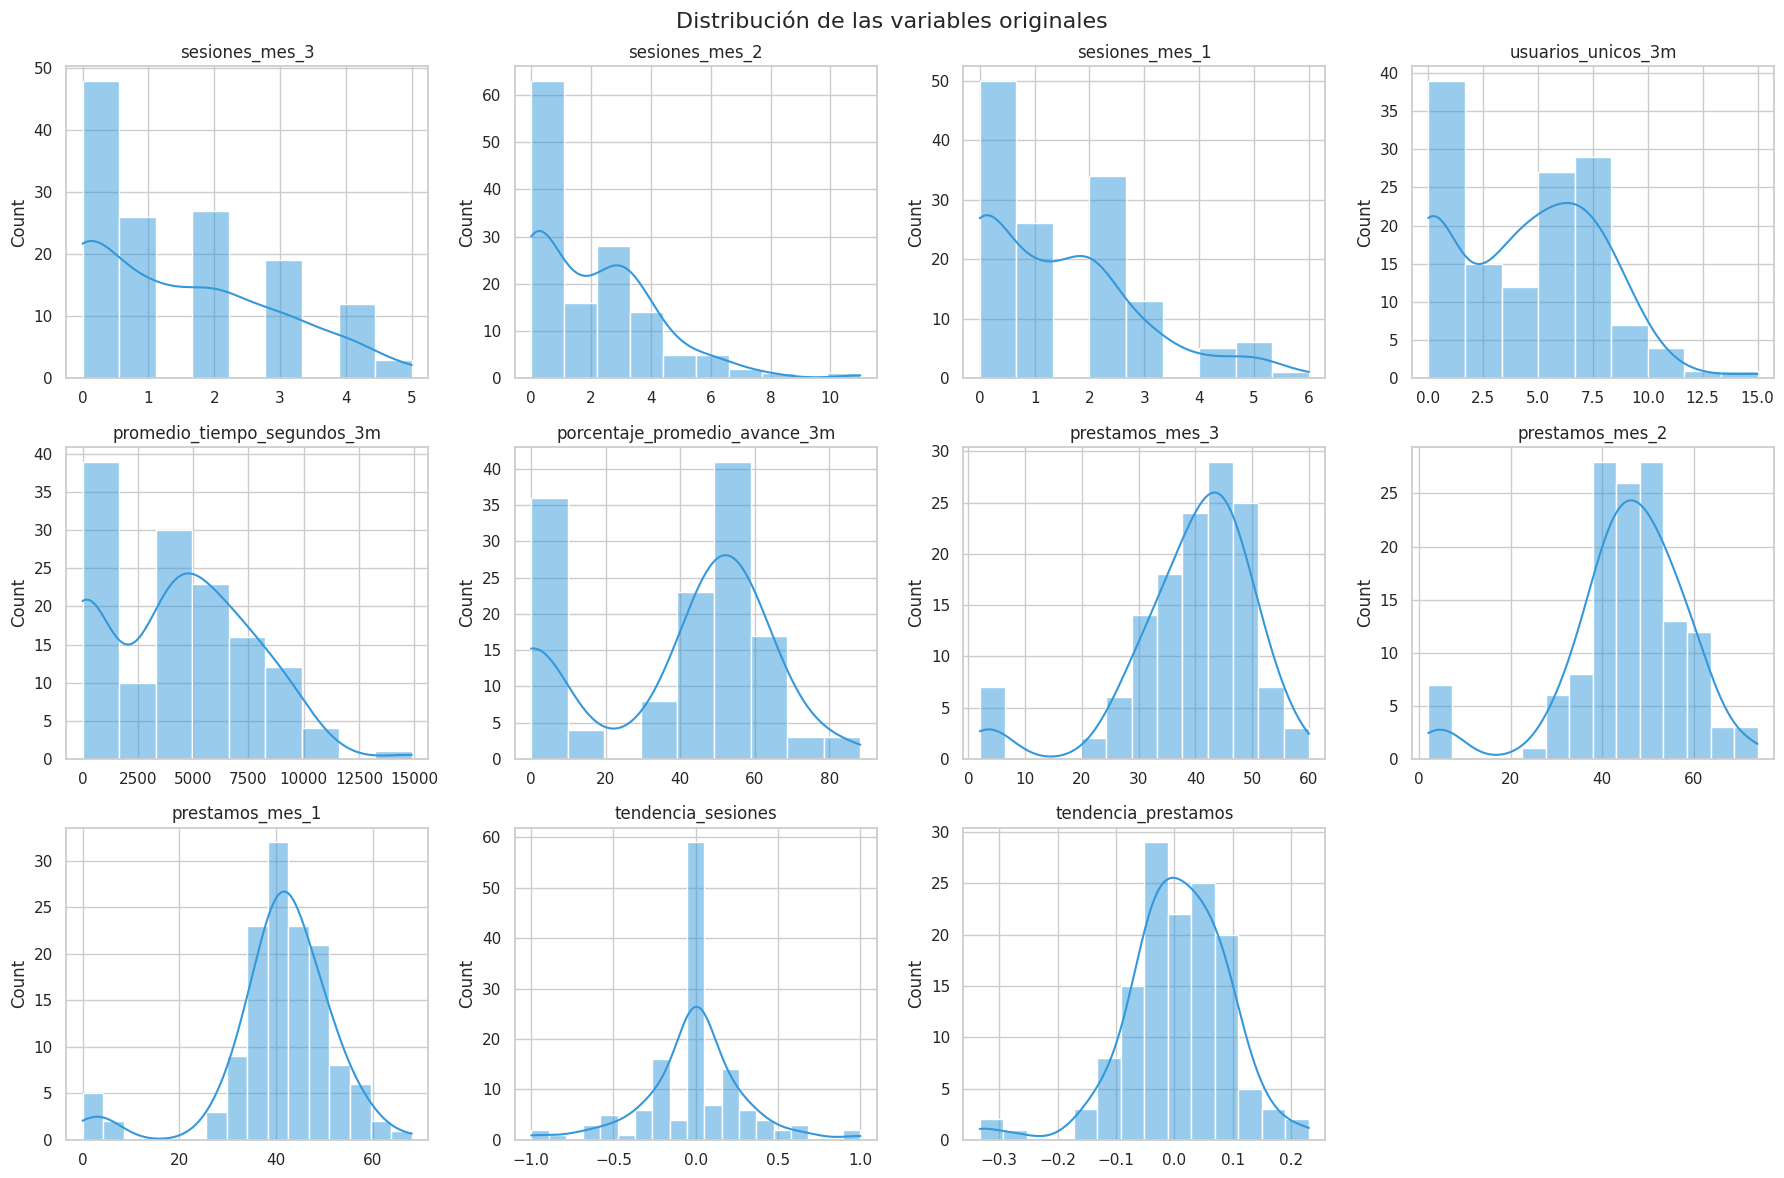

In [7]:
# Distribución de las once variables
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for ax, variable in zip(axes, VARIABLES_X):
    sns.histplot(df[variable], kde=True, ax=ax, color='#3498db')
    ax.set_title(variable)
    ax.set_xlabel('')
axes[-1].axis('off')
fig.suptitle('Distribución de las variables originales', fontsize=16)
plt.tight_layout()
plt.show()

> **Interpretación breve:** la mayoría de los libros se concentra en niveles bajos o medios y unos cuantos alcanzan valores altos. No significa que esos libros estén mal registrados: refleja que la atención y la circulación no se reparten de forma uniforme. También se observa que el uso digital y el físico no siempre crecen juntos, por lo que ambos aportan información diferente al agrupamiento.

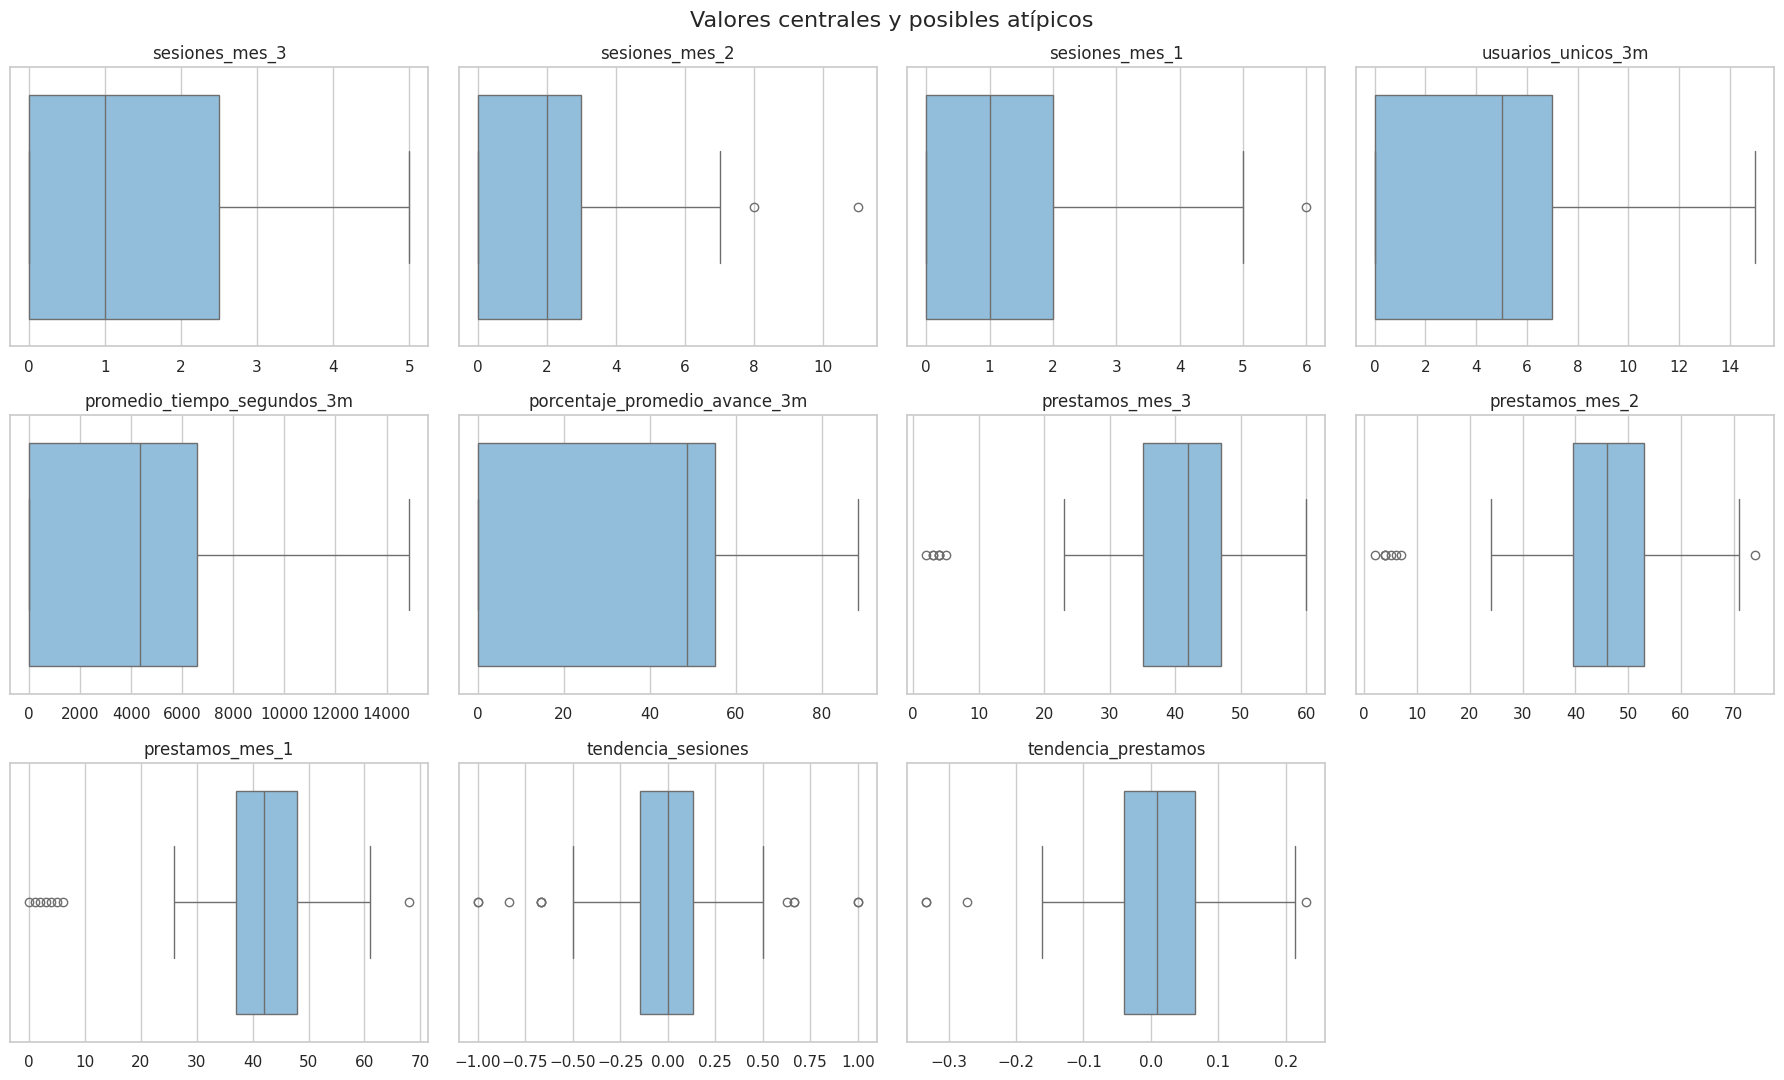

In [8]:
# Diagramas de caja para localizar valores extremos sin eliminarlos
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, variable in zip(axes, VARIABLES_X):
    sns.boxplot(x=df[variable], ax=ax, color='#85c1e9')
    ax.set_title(variable)
    ax.set_xlabel('')
axes[-1].axis('off')
fig.suptitle('Valores centrales y posibles atípicos', fontsize=16)
plt.tight_layout()
plt.show()

> **Pregunta e interpretación:** ¿hay asimetrías o casos extremos que deban eliminarse? Las variables de actividad son asimétricas: pocos libros concentran uso alto. Los puntos fuera del rango IQR se conservan porque son observaciones reales de alta demanda y justamente aportan información al clustering; no se consideran errores solo por ser extremos.

In [9]:
# Conteo de posibles atípicos mediante IQR; es diagnóstico, no filtro.
reporte_atipicos = []
for variable in VARIABLES_X:
    q1, q3 = df[variable].quantile([0.25, 0.75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    cantidad = int(((df[variable] < inferior) | (df[variable] > superior)).sum())
    reporte_atipicos.append({
        'variable': variable,
        'limite_inferior': inferior,
        'limite_superior': superior,
        'posibles_atipicos': cantidad,
        'porcentaje': cantidad / len(df) * 100,
    })
pd.DataFrame(reporte_atipicos).round(2)

,variable,limite_inferior,limite_superior,posibles_atipicos,porcentaje
0,sesiones_mes_3,-3.750,6.250,0,0.000
1,sesiones_mes_2,-4.500,7.500,2,1.480
2,sesiones_mes_1,-3.000,5.000,1,0.740
3,usuarios_unicos_3m,-10.500,17.500,0,0.000
4,promedio_tiempo_segundos_3m,-9876.740,16461.240,0,0.000
5,porcentaje_promedio_avance_3m,-82.700,137.840,0,0.000
6,prestamos_mes_3,17.000,65.000,7,5.190
7,prestamos_mes_2,19.250,73.250,8,5.930
8,prestamos_mes_1,20.500,64.500,8,5.930
9,tendencia_sesiones,-0.570,0.550,11,8.150


#### 2.4.1 Comportamiento mensual agregado

,mes,sesiones_digitales,prestamos_fisicos
0,Octubre 2025,200,5330
1,Noviembre 2025,279,6143
2,Diciembre 2025,189,5504


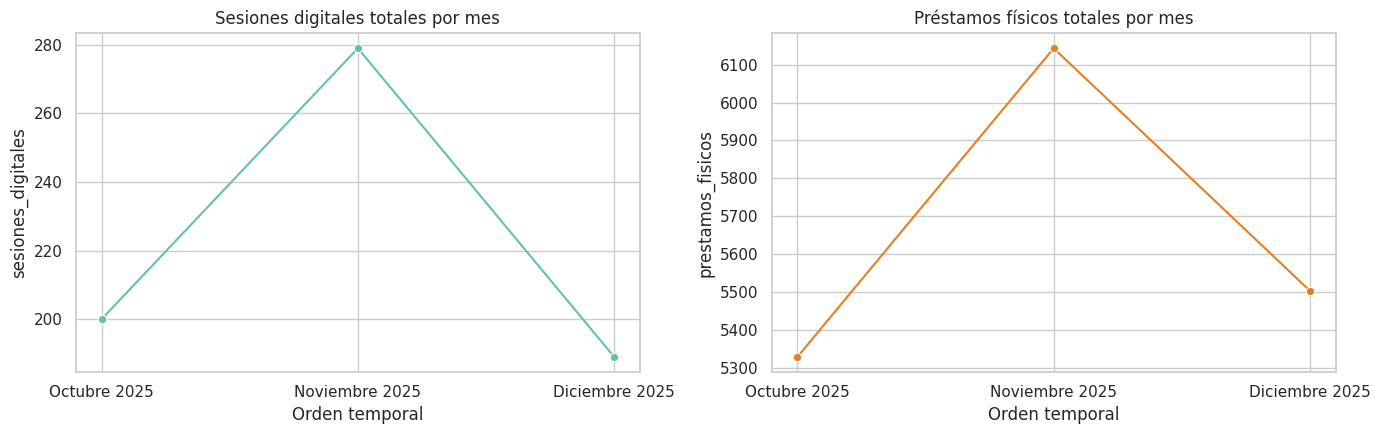

In [10]:
SESIONES = ['sesiones_mes_3', 'sesiones_mes_2', 'sesiones_mes_1']
PRESTAMOS = ['prestamos_mes_3', 'prestamos_mes_2', 'prestamos_mes_1']
PROFUNDIDAD = [
    'usuarios_unicos_3m',
    'promedio_tiempo_segundos_3m',
    'porcentaje_promedio_avance_3m',
]
ETIQUETAS_MESES = ['Octubre 2025', 'Noviembre 2025', 'Diciembre 2025']

actividad_mensual = pd.DataFrame({
    'mes': ETIQUETAS_MESES,
    'sesiones_digitales': df[SESIONES].sum().to_numpy(),
    'prestamos_fisicos': df[PRESTAMOS].sum().to_numpy(),
})
display(actividad_mensual)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=actividad_mensual, x='mes', y='sesiones_digitales', marker='o', ax=axes[0])
sns.lineplot(data=actividad_mensual, x='mes', y='prestamos_fisicos', marker='o', ax=axes[1], color='#e67e22')
axes[0].set_title('Sesiones digitales totales por mes')
axes[1].set_title('Préstamos físicos totales por mes')
for ax in axes:
    ax.set_xlabel('Orden temporal')
plt.tight_layout()
plt.show()

> **Pregunta e interpretación:** ¿la actividad se mantiene igual durante la ventana? Las sesiones suman 200 en octubre, 279 en noviembre y 189 en diciembre; los préstamos suman 5,330, 6,143 y 5,504. Noviembre es el mes de mayor actividad en ambos canales, por lo que conservar las tres columnas mensuales permite distinguir este cambio en vez de ocultarlo en un total trimestral.

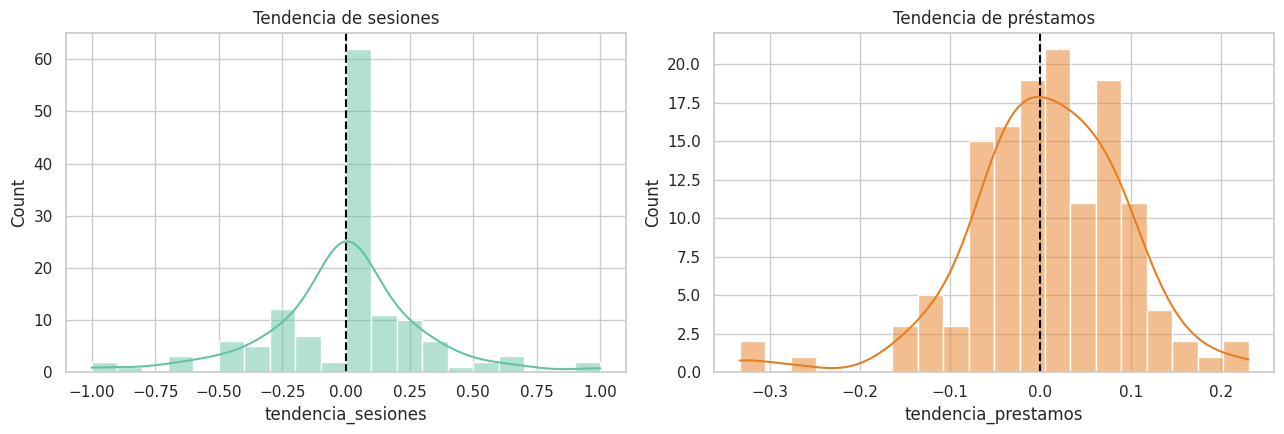

In [11]:
# Distribución de las tendencias
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['tendencia_sesiones'], bins=20, kde=True, ax=axes[0])
sns.histplot(df['tendencia_prestamos'], bins=20, kde=True, ax=axes[1], color='#e67e22')
axes[0].axvline(0, color='black', linestyle='--')
axes[1].axvline(0, color='black', linestyle='--')
axes[0].set_title('Tendencia de sesiones')
axes[1].set_title('Tendencia de préstamos')
plt.tight_layout()
plt.show()

> **Interpretación temporal.** En sesiones hay 39 tendencias positivas, 58 sin cambio y 38 negativas. En préstamos hay 71 positivas, 3 sin cambio y 61 negativas. Esto muestra diversidad de evolución, no una dirección artificial común a todos los libros.

#### 2.4.2 Correlaciones, variabilidad y riesgo de redundancia

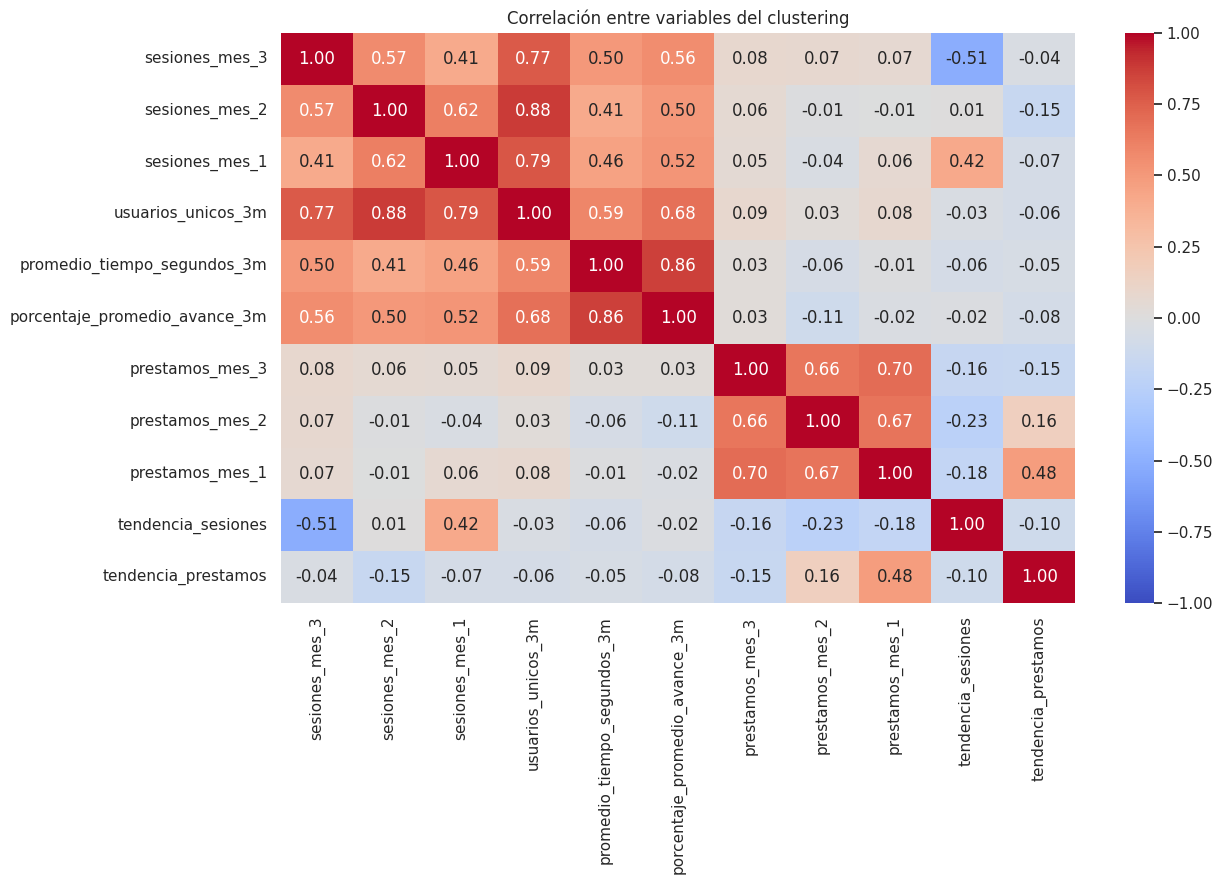

,variable_1,variable_2,correlacion
0,sesiones_mes_2,usuarios_unicos_3m,0.876
1,promedio_tiempo_segundos_3m,porcentaje_promedio_avance_3m,0.862


In [12]:
correlaciones = df[VARIABLES_X].corr()
plt.figure(figsize=(13, 9))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre variables del clustering')
plt.tight_layout()
plt.show()

correlaciones_altas = []
for i, variable_a in enumerate(VARIABLES_X):
    for variable_b in VARIABLES_X[i + 1:]:
        valor = correlaciones.loc[variable_a, variable_b]
        if abs(valor) >= 0.80:
            correlaciones_altas.append({
                'variable_1': variable_a,
                'variable_2': variable_b,
                'correlacion': valor,
            })
pd.DataFrame(correlaciones_altas).round(3)

> **Pregunta e interpretación:** ¿hay variables redundantes? Una correlación alta no implica error: más sesiones puede relacionarse con más lectores y más tiempo con mayor avance. Se conservan porque describen volumen y profundidad, aunque esta redundancia parcial puede darles mayor peso y deberá reevaluarse en futuros reentrenamientos. Ninguna variable es constante; las tendencias, aun con valores pequeños, muestran variación suficiente.

**Sesgos y límites:** el modelo favorece patrones de actividad observada, no calidad bibliográfica; libros nuevos o especializados pueden parecer de baja demanda. Tampoco existe una etiqueta verdadera con la cual medir exactitud externa.

## 3. Preparación de los datos (CRISP-DM)

### 3.1 Selección, limpieza y escalado

K-Means y Ward trabajan con distancias. `StandardScaler` evita que los segundos de lectura y los préstamos —por tener escalas numéricas mayores— dominen el agrupamiento.

No se define `y` porque el problema es no supervisado. No se realiza una partición entrenamiento/prueba: no hay etiquetas que predecir y solo se dispone de una ventana agregada. La evaluación usa cohesión y separación internas, comparación de configuraciones y revisión de estabilidad. El escalador se guarda junto con el modelo en un `Pipeline` para impedir diferencias entre entrenamiento y despliegue.

In [13]:
X = df[VARIABLES_X].copy()
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)
X_escalado_df = pd.DataFrame(X_escalado, columns=VARIABLES_X, index=df.index)

diagnostico_escalado = pd.DataFrame({
    'media': X_escalado_df.mean(),
    'desviacion': X_escalado_df.std(ddof=0),
}).round(4)
diagnostico_escalado

,media,desviacion
sesiones_mes_3,0.000,1.000
sesiones_mes_2,-0.000,1.000
sesiones_mes_1,0.000,1.000
usuarios_unicos_3m,-0.000,1.000
promedio_tiempo_segundos_3m,0.000,1.000
porcentaje_promedio_avance_3m,0.000,1.000
prestamos_mes_3,0.000,1.000
prestamos_mes_2,-0.000,1.000
prestamos_mes_1,-0.000,1.000
tendencia_sesiones,-0.000,1.000


## 4. Modelado (CRISP-DM)

### 4.1 Fundamento y configuraciones comparadas

K-Means representa cada grupo mediante un centroide y asigna cada observación al centroide más cercano, minimizando la suma de distancias cuadráticas dentro de los grupos (inercia). Es adecuado para crear segmentos reutilizables porque permite asignar una nueva ventana mediante `predict()`.

**Supuestos y límites:** usa distancia euclidiana, funciona mejor con grupos compactos y es sensible a escala, valores extremos e inicialización. Por eso se estandariza, se usa `k-means++`, 20 inicializaciones, máximo 300 iteraciones y semilla fija 42. El dendrograma de Ward se conserva solamente como evidencia visual sobre la estructura de los datos; el único modelo entrenado e integrado es K-Means.

Se comparan `k=2` a `k=8` mediante inercia, Silhouette, Davies-Bouldin y Calinski-Harabasz. Silhouette y Calinski altos son preferibles; Davies-Bouldin bajo indica grupos más compactos y separados.

### 4.2 Evaluación de posibles valores de k

Se comparan `k=2` a `k=8` mediante inercia, Silhouette, Davies-Bouldin y Calinski-Harabasz. La inercia siempre disminuye al agregar grupos; las otras métricas permiten revisar si la separación realmente mejora.

In [14]:
resultados_k = []
modelos_k = {}
for k in range(2, 9):
    modelo_temporal = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    etiquetas = modelo_temporal.fit_predict(X_escalado)
    modelos_k[k] = modelo_temporal
    resultados_k.append({
        'k': k,
        'inercia': modelo_temporal.inertia_,
        'silhouette': silhouette_score(X_escalado, etiquetas),
        'davies_bouldin': davies_bouldin_score(X_escalado, etiquetas),
        'calinski_harabasz': calinski_harabasz_score(X_escalado, etiquetas),
        'cluster_menor': int(pd.Series(etiquetas).value_counts().min()),
    })

evaluacion_k = pd.DataFrame(resultados_k)
evaluacion_k['reduccion_inercia_pct'] = -evaluacion_k['inercia'].pct_change() * 100
evaluacion_k.round(4)

,k,inercia,silhouette,davies_bouldin,calinski_harabasz,cluster_menor,reduccion_inercia_pct
0,2,1040.357,0.342,1.231,56.843,43,NaN
1,3,820.234,0.356,1.014,53.490,7,21.158
2,4,701.412,0.282,1.455,48.783,7,14.486
3,5,630.252,0.287,1.187,44.077,1,10.145
4,6,569.917,0.269,1.306,41.426,1,9.573
5,7,514.905,0.279,1.254,40.193,1,9.653
6,8,475.417,0.289,1.133,38.528,1,7.669


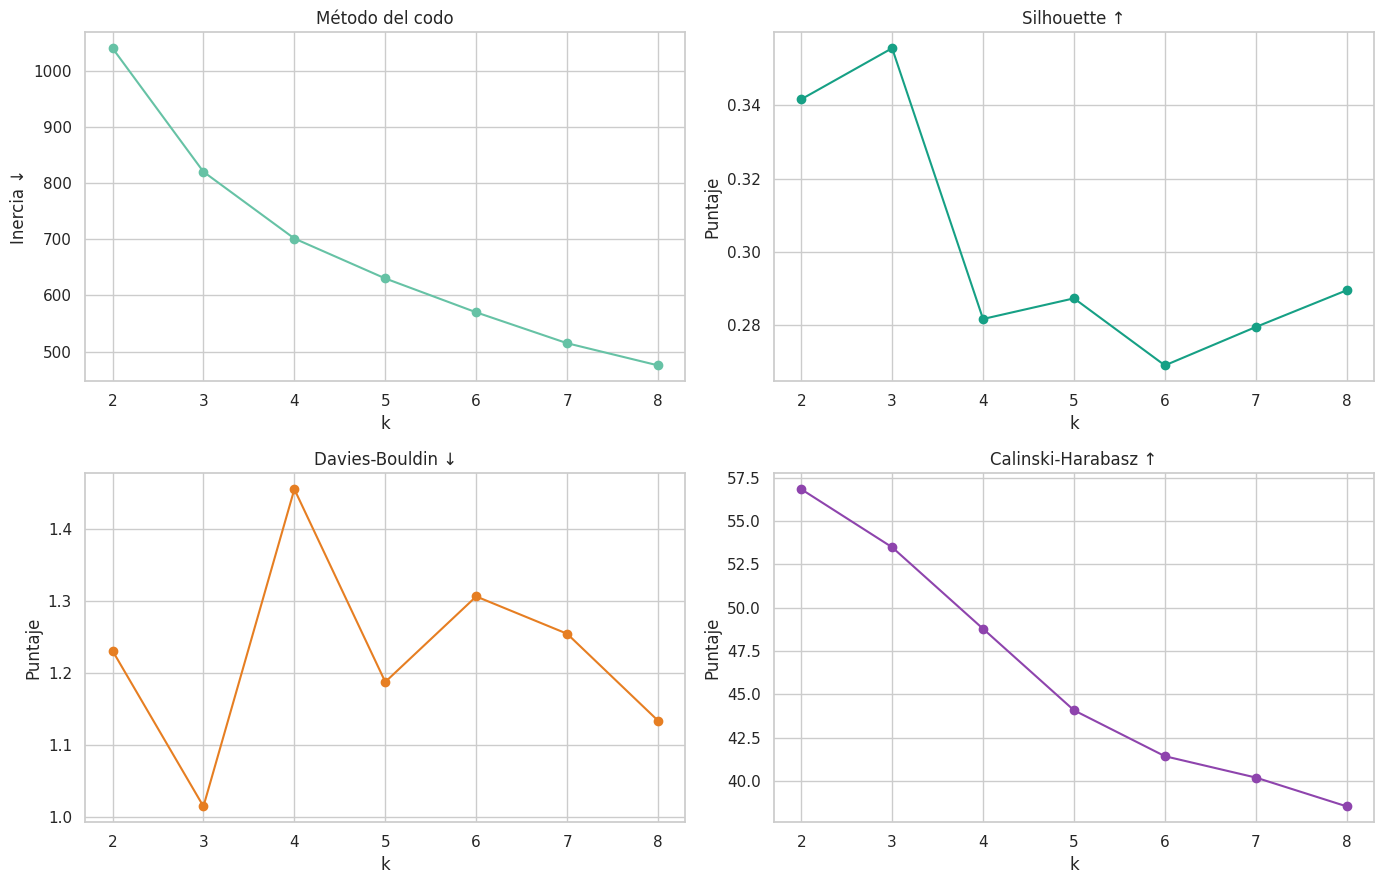

{'Silhouette': 3, 'Davies-Bouldin': 3, 'Calinski-Harabasz': 2}

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(evaluacion_k['k'], evaluacion_k['inercia'], marker='o')
axes[0, 0].set(title='Método del codo', xlabel='k', ylabel='Inercia ↓')
axes[0, 1].plot(evaluacion_k['k'], evaluacion_k['silhouette'], marker='o', color='#16a085')
axes[0, 1].set(title='Silhouette ↑', xlabel='k', ylabel='Puntaje')
axes[1, 0].plot(evaluacion_k['k'], evaluacion_k['davies_bouldin'], marker='o', color='#e67e22')
axes[1, 0].set(title='Davies-Bouldin ↓', xlabel='k', ylabel='Puntaje')
axes[1, 1].plot(evaluacion_k['k'], evaluacion_k['calinski_harabasz'], marker='o', color='#8e44ad')
axes[1, 1].set(title='Calinski-Harabasz ↑', xlabel='k', ylabel='Puntaje')
plt.tight_layout()
plt.show()

mejores_k = {
    'Silhouette': int(evaluacion_k.loc[evaluacion_k['silhouette'].idxmax(), 'k']),
    'Davies-Bouldin': int(evaluacion_k.loc[evaluacion_k['davies_bouldin'].idxmin(), 'k']),
    'Calinski-Harabasz': int(evaluacion_k.loc[evaluacion_k['calinski_harabasz'].idxmax(), 'k']),
}
mejores_k

,k,inercia,reduccion_inercia_pct
0,2,1040.360,NaN
1,3,820.230,21.160
2,4,701.410,14.490
3,5,630.250,10.150
4,6,569.920,9.570
5,7,514.900,9.650
6,8,475.420,7.670


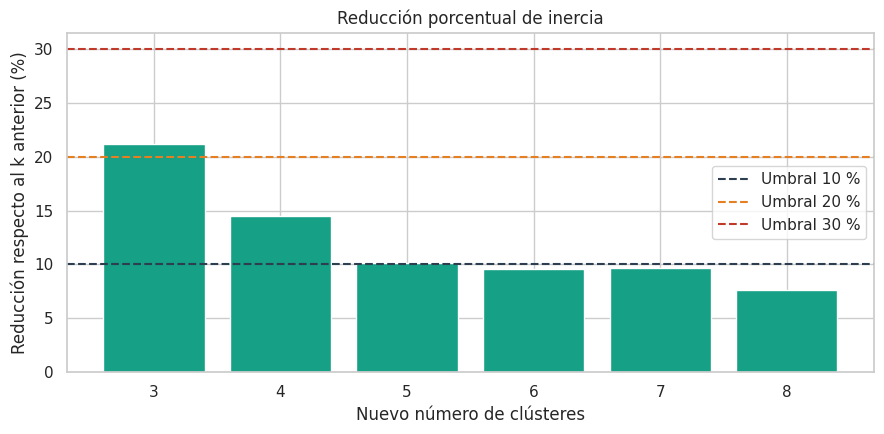

In [16]:
# Reducción porcentual de inercia como evidencia complementaria
display(evaluacion_k[['k', 'inercia', 'reduccion_inercia_pct']].round(2))
plt.figure(figsize=(9, 4.5))
valores = evaluacion_k.dropna(subset=['reduccion_inercia_pct'])
plt.bar(valores['k'], valores['reduccion_inercia_pct'], color='#16a085')
for umbral, color in [(10, '#2c3e50'), (20, '#e67e22'), (30, '#c0392b')]:
    plt.axhline(umbral, color=color, linestyle='--', label=f'Umbral {umbral} %')
plt.title('Reducción porcentual de inercia')
plt.xlabel('Nuevo número de clústeres')
plt.ylabel('Reducción respecto al k anterior (%)')
plt.legend()
plt.tight_layout()
plt.show()

> **Interpretación breve:** la inercia siempre baja cuando se agregan grupos, pero eso no significa que más grupos sean automáticamente mejores. El salto de 2 a 3 permite separar un comportamiento particular; después, la mejora se vuelve progresivamente menos útil y se crean divisiones más difíciles de convertir en acciones distintas para la biblioteca.

### 4.3 Dendrograma jerárquico completo

El dendrograma muestra los 135 libros, sin truncamiento. La línea roja se coloca entre las fusiones que pasan de tres a dos grupos; cortar horizontalmente en esa altura produce tres ramas principales. Es evidencia complementaria y no reemplaza las métricas de K-Means.

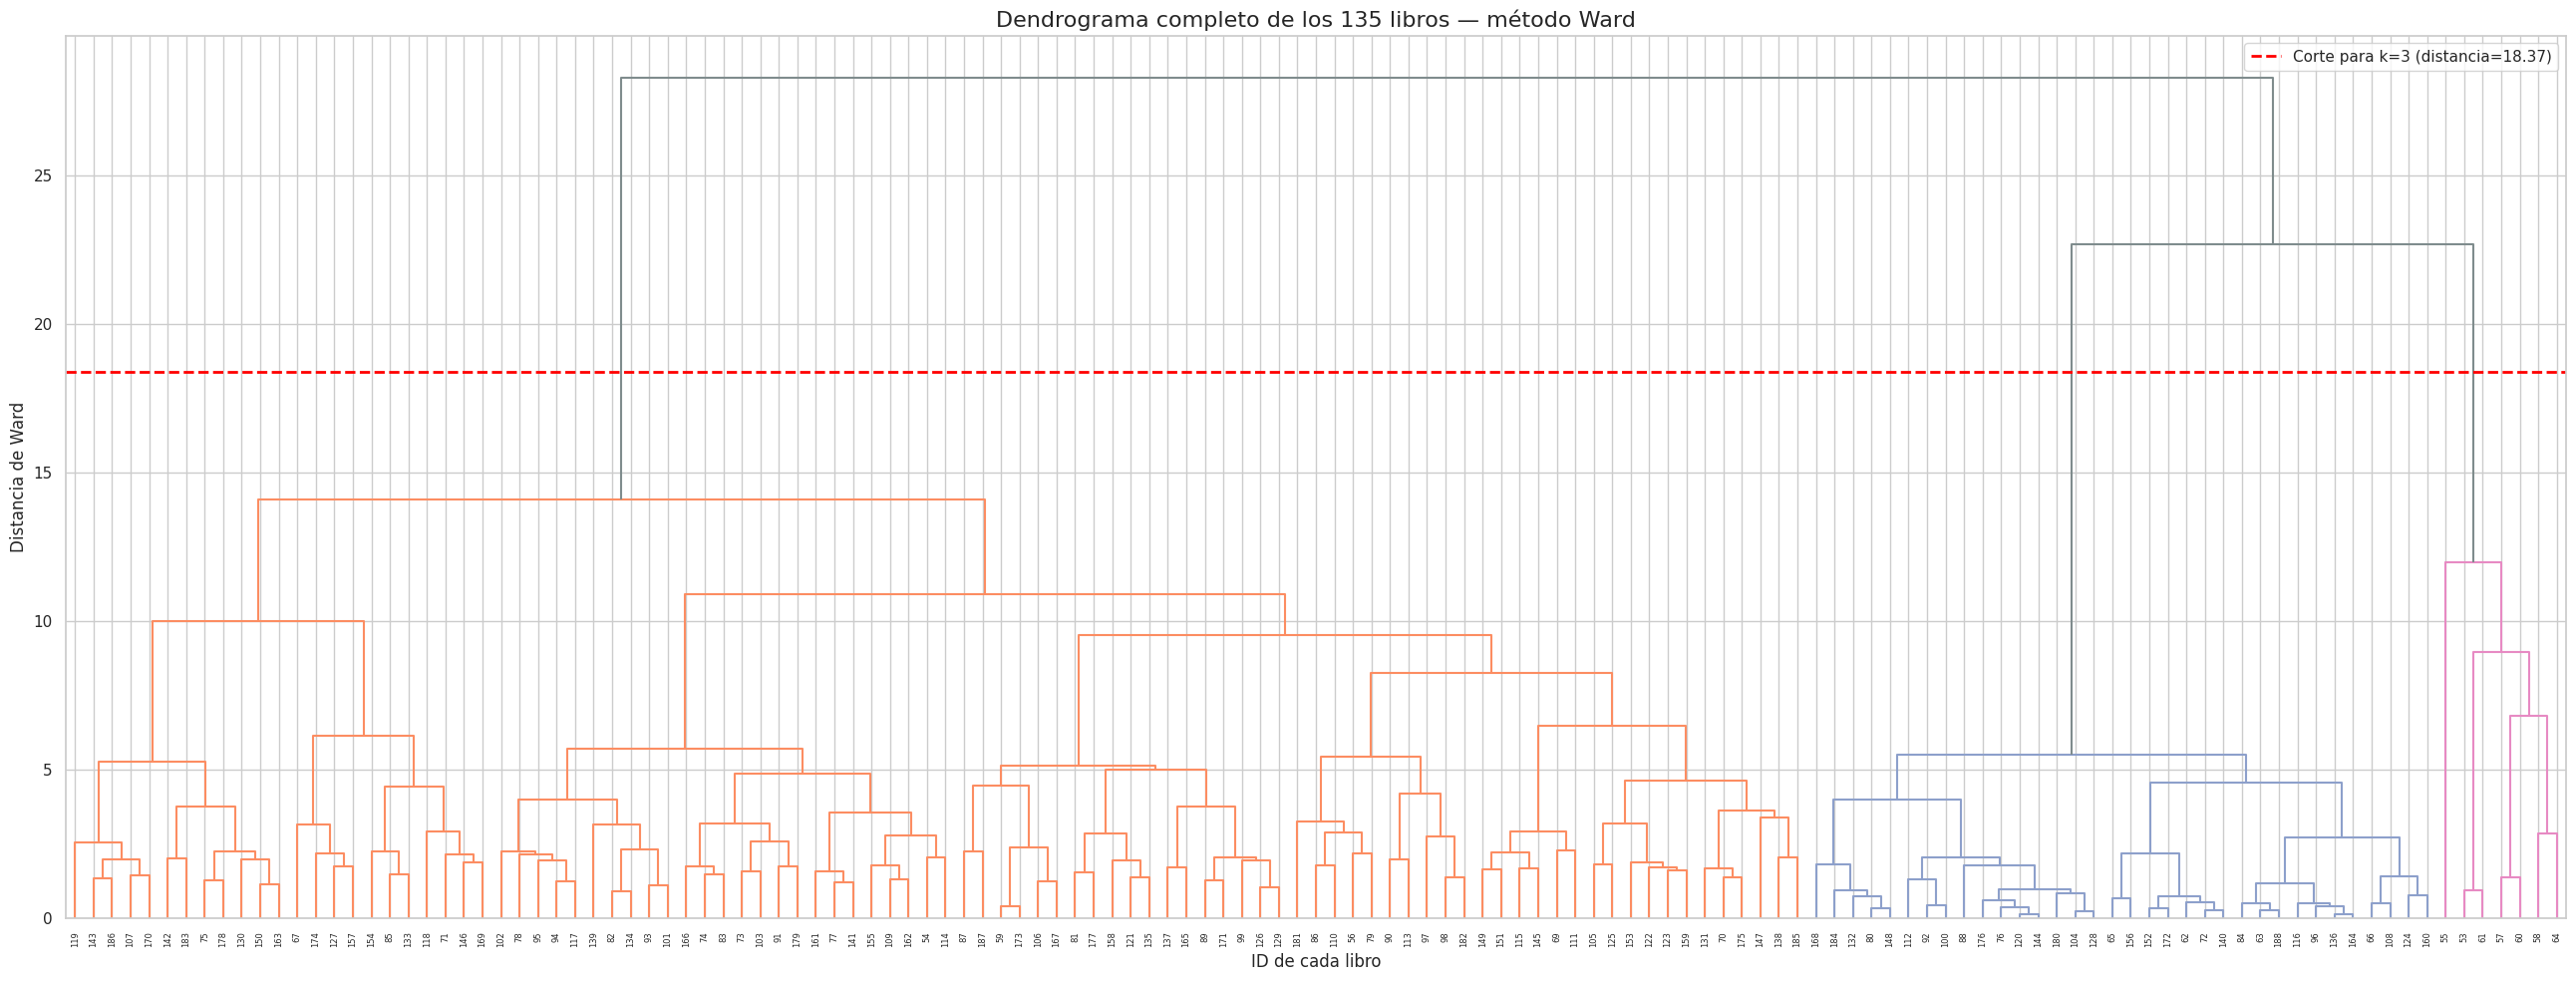

Altura de corte: 18.372. Ramas principales debajo del corte: 3.


In [17]:
K_SELECCIONADO = 3
matriz_enlace = linkage(X_escalado, method='ward')
distancia_inferior = matriz_enlace[-K_SELECCIONADO, 2]
distancia_superior = matriz_enlace[-(K_SELECCIONADO - 1), 2]
altura_corte = (distancia_inferior + distancia_superior) / 2

plt.figure(figsize=(26, 10))
dendrogram(
    matriz_enlace,
    labels=df['libro_id'].astype(str).to_numpy(),
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=altura_corte,
    above_threshold_color='#7f8c8d',
)
plt.axhline(
    altura_corte,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Corte para k={K_SELECCIONADO} (distancia={altura_corte:.2f})',
)
plt.title('Dendrograma completo de los 135 libros — método Ward', fontsize=16)
plt.xlabel('ID de cada libro')
plt.ylabel('Distancia de Ward')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'Altura de corte: {altura_corte:.3f}. Ramas principales debajo del corte: {K_SELECCIONADO}.')

> **Interpretación:** la línea roja no significa que el dendrograma “vote” por sí solo. Indica visualmente dónde se corta el árbol para obtener tres grupos, decisión que se acepta únicamente después de contrastarla con Silhouette, Davies-Bouldin, Calinski-Harabasz, tamaño de grupos y utilidad operativa.

## 5. Evaluación (CRISP-DM)

### 5.1 Selección final de k

Con el dataset final, `k=3` obtiene la mayor Silhouette y el menor Davies-Bouldin. Calinski-Harabasz favorece `k=2`, pero tres grupos mantienen una interpretación operativa útil y el grupo menor conserva siete libros. A partir de cuatro grupos disminuye la separación y aparecen subdivisiones menos estables.

La elección no se deriva de una sola gráfica ni se fija antes de evaluar.

In [18]:
K_FINAL = 3
modelo = modelos_k[K_FINAL]
etiquetas_cluster = modelo.labels_

df_resultado = df.copy()
df_resultado['cluster'] = etiquetas_cluster

metricas_finales = pd.DataFrame({
    'metrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'resultado': [
        silhouette_score(X_escalado, etiquetas_cluster),
        davies_bouldin_score(X_escalado, etiquetas_cluster),
        calinski_harabasz_score(X_escalado, etiquetas_cluster),
    ],
})
display(metricas_finales.round(4))
df_resultado['cluster'].value_counts().sort_index().rename('libros').to_frame()

,metrica,resultado
0,Silhouette,0.356
1,Davies-Bouldin,1.014
2,Calinski-Harabasz,53.490


,libros
cluster,
0,36
1,92
2,7


#### ¿Por qué un clúster contiene solamente 7 libros?

El resultado actual distribuye los 135 libros en **36, 92 y 7**. El grupo de siete no se creó imponiendo ese tamaño: K-Means ubicó juntos esos libros porque combinan préstamos físicos muy bajos —aproximadamente 3 a 5 por mes— con actividad digital y una tendencia digital positiva. Esa combinación es poco frecuente dentro del catálogo y por eso constituye un segmento pequeño.

El identificador `cluster = 2` no representa jerarquía, calidad ni una posición permanente. K-Means puede intercambiar los números 0, 1 y 2 aunque conserve exactamente los mismos grupos; por ello la aplicación debe usar también `nombre_cluster`. Si anteriormente aparecían cantidades distintas, las causas posibles son una ventana mensual diferente, otro conjunto de columnas, otra versión del dataset o una configuración distinta del modelo. Con el CSV actual, las 11 variables establecidas y semilla 42, el resultado es reproducible: 36, 92 y 7.

El grupo pequeño no se descarta: se revisa mediante Silhouette individual y deberá vigilarse en nuevas ventanas. Si pierde separación o cambia bruscamente, corresponderá reentrenar y revisar los perfiles.

### 5.2 Perfiles, estabilidad y casos difíciles

In [19]:
perfil_original = df_resultado.groupby('cluster')[VARIABLES_X].mean()
perfil_estandarizado = (
    X_escalado_df.assign(cluster=etiquetas_cluster)
    .groupby('cluster')[VARIABLES_X]
    .mean()
)

puntaje_digital = perfil_estandarizado[SESIONES + PROFUNDIDAD].mean(axis=1)
puntaje_fisico = perfil_estandarizado[PRESTAMOS].mean(axis=1)
cluster_fisico_bajo = int(puntaje_fisico.idxmin())
restantes = [int(c) for c in perfil_original.index if int(c) != cluster_fisico_bajo]
cluster_digital_bajo = int(puntaje_digital.loc[restantes].idxmin())
cluster_integral = next(c for c in restantes if c != cluster_digital_bajo)

NOMBRES_CLUSTER = {
    cluster_digital_bajo: 'Uso principalmente físico',
    cluster_integral: 'Uso integral intensivo',
    cluster_fisico_bajo: 'Uso digital emergente',
}
df_resultado['nombre_cluster'] = df_resultado['cluster'].map(NOMBRES_CLUSTER)

perfil_original.insert(0, 'libros', df_resultado.groupby('cluster').size())
perfil_original.insert(1, 'nombre_cluster', pd.Series(NOMBRES_CLUSTER))
perfil_original.round(2)

,libros,nombre_cluster,sesiones_mes_3,sesiones_mes_2,sesiones_mes_1,usuarios_unicos_3m,promedio_tiempo_segundos_3m,porcentaje_promedio_avance_3m,prestamos_mes_3,prestamos_mes_2,prestamos_mes_1,tendencia_sesiones,tendencia_prestamos
cluster,,,,,,,,,,,,,
0,36,Uso principalmente físico,0.080,0.030,0.060,0.140,96.230,0.790,41.330,49.690,43.220,0.000,0.010
1,92,Uso integral intensivo,2.090,2.880,1.930,6.110,5910.300,52.720,41.490,46.980,42.680,-0.040,0.010
2,7,Uso digital emergente,0.710,1.860,1.290,2.860,3845.210,36.250,3.570,4.570,3.000,0.360,-0.090


In [20]:
# Calidad de asignación por grupo mediante Silhouette individual
silhouette_individual = silhouette_samples(X_escalado, etiquetas_cluster)
estabilidad = pd.DataFrame({
    'cluster': etiquetas_cluster,
    'silhouette_individual': silhouette_individual,
}).groupby('cluster').agg(
    libros=('silhouette_individual', 'size'),
    silhouette_promedio=('silhouette_individual', 'mean'),
    silhouette_minimo=('silhouette_individual', 'min'),
    asignaciones_negativas=('silhouette_individual', lambda s: int((s < 0).sum())),
)
estabilidad['nombre_cluster'] = pd.Series(NOMBRES_CLUSTER)
estabilidad.round(3)

,libros,silhouette_promedio,silhouette_minimo,asignaciones_negativas,nombre_cluster
cluster,,,,,
0,36,0.632,0.173,0,Uso principalmente físico
1,92,0.262,-0.095,4,Uso integral intensivo
2,7,0.166,-0.018,1,Uso digital emergente


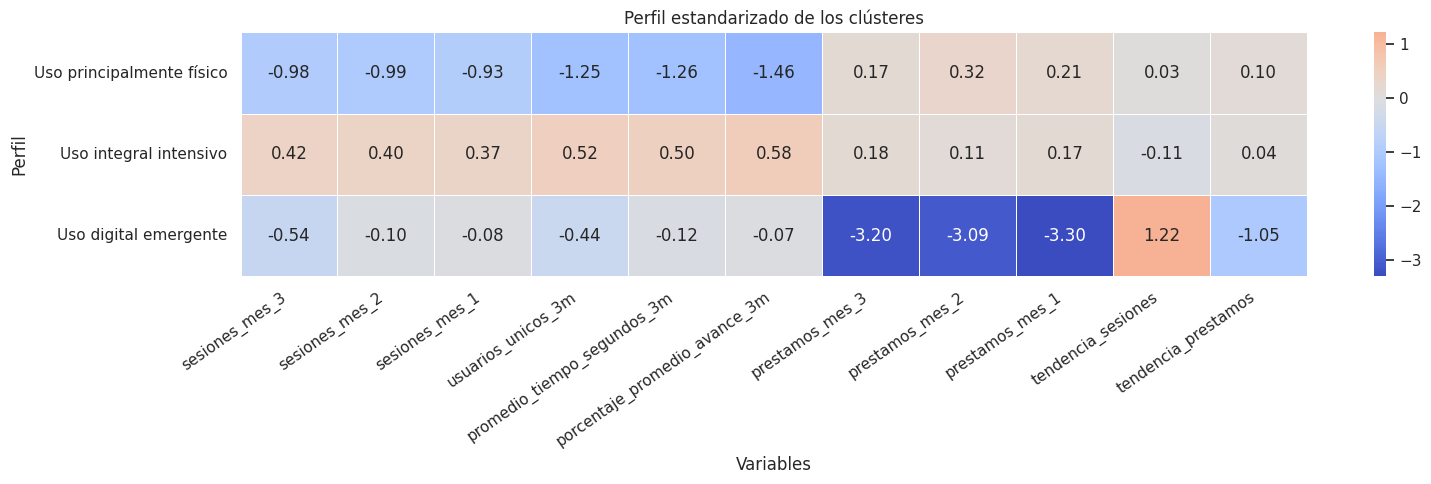

In [21]:
perfil_mapa = perfil_estandarizado.rename(index=NOMBRES_CLUSTER)
plt.figure(figsize=(16, 5))
sns.heatmap(perfil_mapa, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Perfil estandarizado de los clústeres')
plt.xlabel('Variables')
plt.ylabel('Perfil')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

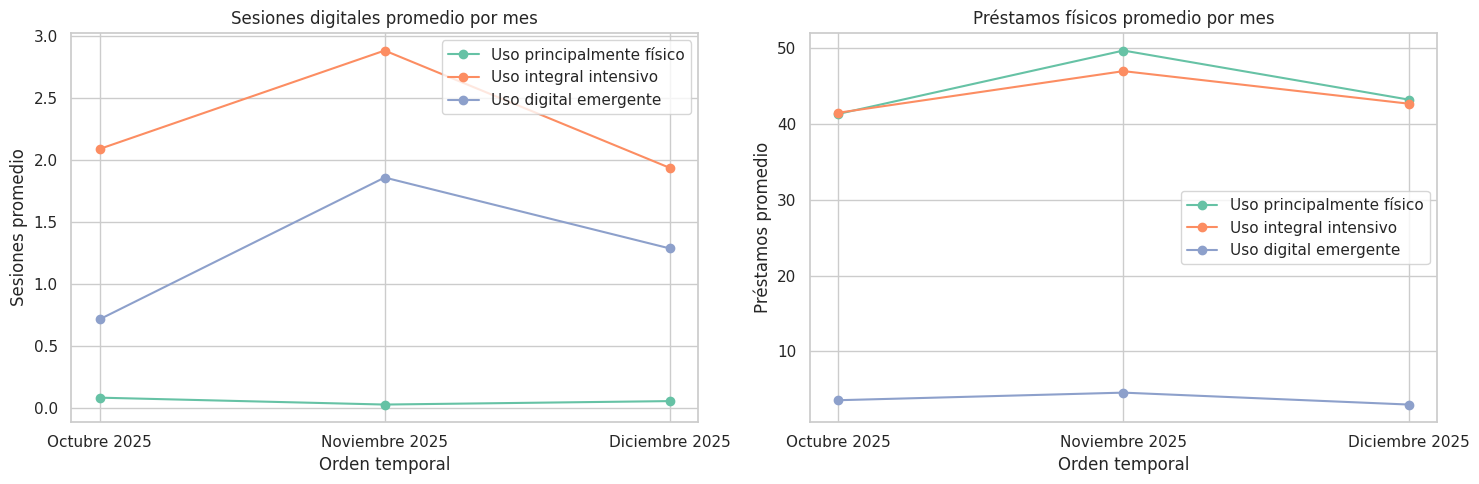

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for cluster in perfil_original.index:
    nombre = NOMBRES_CLUSTER[int(cluster)]
    axes[0].plot(ETIQUETAS_MESES, perfil_original.loc[cluster, SESIONES], marker='o', label=nombre)
    axes[1].plot(ETIQUETAS_MESES, perfil_original.loc[cluster, PRESTAMOS], marker='o', label=nombre)
axes[0].set(title='Sesiones digitales promedio por mes', ylabel='Sesiones promedio')
axes[1].set(title='Préstamos físicos promedio por mes', ylabel='Préstamos promedio')
for ax in axes:
    ax.set_xlabel('Orden temporal')
    ax.legend()
plt.tight_layout()
plt.show()

### Lectura de los perfiles

- **Uso principalmente físico — 36 libros:** casi no registra lectura digital (menos de 0.1 sesiones promedio por mes), pero mantiene aproximadamente 41, 50 y 43 préstamos. Son materiales consultados mediante ejemplares físicos.
- **Uso integral intensivo — 92 libros:** presenta el mayor uso digital, alrededor de 6.1 usuarios únicos, 5,910 segundos y 52.7 % de avance, además de aproximadamente 41 a 47 préstamos mensuales. Es el comportamiento dominante del catálogo.
- **Uso digital emergente — 7 libros:** mantiene solamente entre 3 y 5 préstamos promedio por mes, pero muestra actividad digital y una tendencia de sesiones positiva cercana a 0.36. Es pequeño porque esa combinación es poco común.

En términos humanos: un grupo se usa principalmente desde el estante, otro funciona bien tanto en línea como físicamente y el tercero comienza a llamar la atención en digital aunque casi no circule físicamente. Los perfiles describen comportamiento, no calidad académica ni afinidad temática.

In [23]:
INTERPRETACION = {
    'Uso principalmente físico': 'Demanda concentrada en préstamos físicos y presencia digital mínima.',
    'Uso integral intensivo': 'Uso digital alto y profundo, acompañado por circulación física estable.',
    'Uso digital emergente': 'Circulación física muy baja y actividad digital reciente con señal de crecimiento.',
}
ACCION_SUGERIDA = {
    'Uso principalmente físico': 'Revisar disponibilidad digital y promover acceso electrónico sin reducir ejemplares físicos.',
    'Uso integral intensivo': 'Priorizar disponibilidad y recomendar materiales académicamente relacionados.',
    'Uso digital emergente': 'Dar visibilidad digital y comprobar si el crecimiento se mantiene.',
}

resumen_clusters = perfil_original.reset_index()
resumen_clusters['interpretacion'] = resumen_clusters['nombre_cluster'].map(INTERPRETACION)
resumen_clusters['accion_sugerida'] = resumen_clusters['nombre_cluster'].map(ACCION_SUGERIDA)
columnas_resumen = [
    'cluster', 'nombre_cluster', 'libros',
    *SESIONES, *PROFUNDIDAD, *PRESTAMOS,
    'tendencia_sesiones', 'tendencia_prestamos',
    'interpretacion', 'accion_sugerida',
]
resumen_clusters[columnas_resumen].round(2)

,cluster,nombre_cluster,libros,sesiones_mes_3,sesiones_mes_2,sesiones_mes_1,usuarios_unicos_3m,promedio_tiempo_segundos_3m,porcentaje_promedio_avance_3m,prestamos_mes_3,prestamos_mes_2,prestamos_mes_1,tendencia_sesiones,tendencia_prestamos,interpretacion,accion_sugerida
0,0,Uso principalmente físico,36,0.080,0.030,0.060,0.140,96.230,0.790,41.330,49.690,43.220,0.000,0.010,Demanda concentrada en préstamos físicos y pre...,Revisar disponibilidad digital y promover acce...
1,1,Uso integral intensivo,92,2.090,2.880,1.930,6.110,5910.300,52.720,41.490,46.980,42.680,-0.040,0.010,"Uso digital alto y profundo, acompañado por ci...",Priorizar disponibilidad y recomendar material...
2,2,Uso digital emergente,7,0.710,1.860,1.290,2.860,3845.210,36.250,3.570,4.570,3.000,0.360,-0.090,Circulación física muy baja y actividad digita...,Dar visibilidad digital y comprobar si el crec...


### 5.3 Proyección PCA para inspección visual

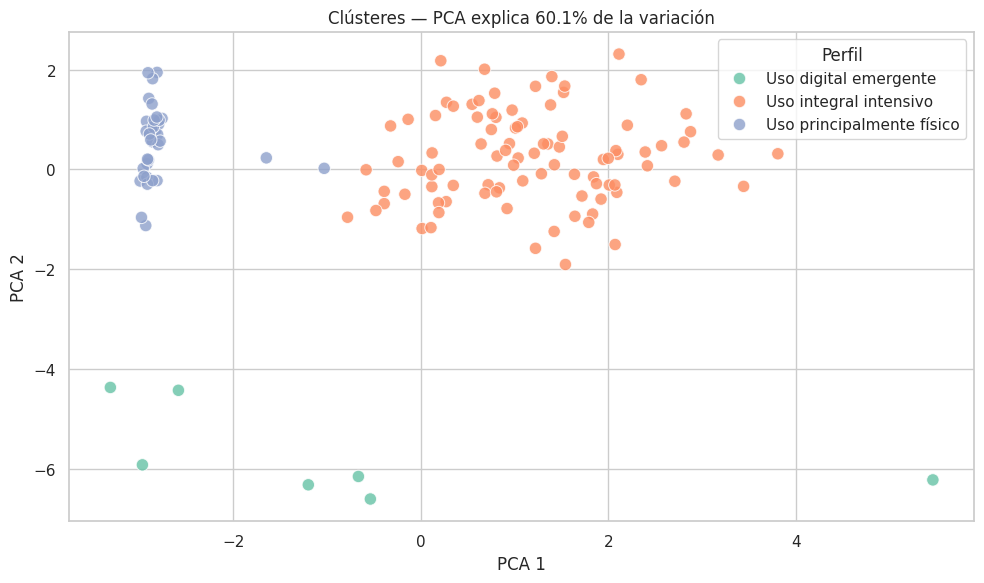

,componente,varianza_explicada
0,PCA 1,0.371
1,PCA 2,0.230
2,Total,0.602


In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordenadas_pca = pca.fit_transform(X_escalado)
grafica_pca = pd.DataFrame({
    'PCA 1': coordenadas_pca[:, 0],
    'PCA 2': coordenadas_pca[:, 1],
    'Perfil': df_resultado['nombre_cluster'],
})
plt.figure(figsize=(10, 6))
sns.scatterplot(data=grafica_pca, x='PCA 1', y='PCA 2', hue='Perfil', s=80, alpha=0.8)
plt.title(f'Clústeres — PCA explica {pca.explained_variance_ratio_.sum():.1%} de la variación')
plt.tight_layout()
plt.show()

pd.DataFrame({
    'componente': ['PCA 1', 'PCA 2', 'Total'],
    'varianza_explicada': [
        pca.explained_variance_ratio_[0],
        pca.explained_variance_ratio_[1],
        pca.explained_variance_ratio_.sum(),
    ],
}).round(4)

> **Interpretación breve:** PCA comprime las 11 variables en dos ejes para poder observarlas en una gráfica. Los puntos cercanos tienen comportamientos parecidos y los alejados son distintos. Puede existir cierto traslape porque la proyección pierde información; por eso PCA no decide los grupos ni reemplaza las métricas calculadas en las 11 dimensiones.

### 5.4 Limitaciones de la evaluación

- Las métricas internas no prueban que exista una única segmentación verdadera.
- El grupo pequeño puede ser sensible a nuevas ventanas; se revisa con Silhouette individual y asignaciones negativas.
- PCA solo proyecta para visualizar y no interviene en el entrenamiento.
- La evaluación deberá repetirse al reentrenar con otra ventana; un cambio fuerte de tamaño o métricas requiere revisión humana.

## 6. Despliegue e integración (CRISP-DM)

### 6.1 Uso en la página

#### Decisión habilitada por cada segmento

| Segmento | Evidencia observada | Decisión o acción | Responsable beneficiado |
|---|---|---|---|
| Uso principalmente físico | 36 libros, lectura digital casi nula y alrededor de 41–50 préstamos mensuales | Mantener ejemplares disponibles, revisar si existe versión digital y promoverla sin retirar soporte físico | Bibliotecario/administrador de catálogo |
| Uso integral intensivo | 92 libros, mayor profundidad digital y circulación física estable | Priorizar disponibilidad, vigilar saturación y mostrarlos dentro de materiales relevantes para continuar estudiando | Estudiante y bibliotecario |
| Uso digital emergente | 7 libros, circulación física muy baja y tendencia digital positiva | Dar visibilidad digital controlada y revisar el siguiente mes si el crecimiento se mantiene antes de tomar decisiones de adquisición | Administrador de contenido y estudiante |

#### Lugar de implementación

1. Al comenzar un mes, el backend consulta los tres meses completos anteriores y reconstruye exactamente las 11 variables.
2. Carga `clustering_libros_mensual.joblib` y ejecuta `pipeline.predict(datos_actuales)`; el escalador guardado se aplica automáticamente.
3. Traduce el número interno mediante `nombres_cluster` y actualiza o consulta el segmento vigente del libro.
4. La página utiliza el nombre para organizar mensajes o secciones, después de filtrar por pertinencia académica, materia o relación temática.

El estudiante no verá números como 0, 1 o 2. Verá una explicación funcional:

- `Uso integral intensivo` → **Continúa estudiando**.
- `Uso principalmente físico` → **Disponible para solicitar**.
- `Uso digital emergente` → **Descubre recursos digitales**.

#### Roles beneficiados

- **Estudiante:** encuentra materiales con señales claras de disponibilidad y uso, sin tener que interpretar métricas técnicas.
- **Bibliotecario:** identifica qué libros requieren conservar disponibilidad física, seguimiento de demanda o revisión de acceso digital.
- **Administrador del sistema/contenido:** puede aplicar reglas consistentes y auditar por qué un libro recibió determinado tratamiento.
- **Responsable académico:** recibe evidencia agregada para apoyar decisiones, pero conserva la revisión humana sobre pertinencia y calidad.

El clustering ordena o presenta candidatos; no reemplaza la recomendación temática ni personal. Tampoco debe ocultar libros únicamente por pertenecer a un grupo de menor uso.

### 6.2 Exportar resultados y artefacto

Se guarda un pipeline con el escalador y K-Means unidos. Esto evita aplicar un escalamiento diferente durante la actualización mensual.

In [25]:
RUTA_SALIDA = Path('resultados_clustering_libros_oct_dic_2025')
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

ruta_libros = RUTA_SALIDA / 'libros_con_cluster_mensual.csv'
ruta_resumen = RUTA_SALIDA / 'resumen_clusters_mensual.csv'
ruta_modelo = RUTA_SALIDA / 'clustering_libros_mensual.joblib'

df_resultado[['libro_id', 'titulo', 'cluster', 'nombre_cluster'] + VARIABLES_X].to_csv(
    ruta_libros, index=False, encoding='utf-8-sig'
)
resumen_clusters[columnas_resumen].to_csv(ruta_resumen, index=False, encoding='utf-8-sig')

pipeline = Pipeline([
    ('escalador', escalador),
    ('kmeans', modelo),
])
joblib.dump({
    'pipeline': pipeline,
    'variables_x': VARIABLES_X,
    'nombres_cluster': NOMBRES_CLUSTER,
    'k': K_FINAL,
    'random_state': RANDOM_STATE,
    'metricas': metricas_finales.set_index('metrica')['resultado'].to_dict(),
}, ruta_modelo)

pd.DataFrame({
    'archivo': [ruta_libros.name, ruta_resumen.name, ruta_modelo.name],
    'ubicacion': [str(ruta_libros), str(ruta_resumen), str(ruta_modelo)],
})

,archivo,ubicacion
0,libros_con_cluster_mensual.csv,resultados_clustering_libros_oct_dic_2025/libr...
1,resumen_clusters_mensual.csv,resultados_clustering_libros_oct_dic_2025/resu...
2,clustering_libros_mensual.joblib,resultados_clustering_libros_oct_dic_2025/clus...


### 6.3 Comprobación de `predict()` mensual

Una nueva ventana debe conservar las mismas 11 variables y el mismo orden. El pipeline cargado escala y asigna el clúster; no vuelve a entrenar centroides.

In [26]:
artefacto = joblib.load(ruta_modelo)
assert artefacto['variables_x'] == VARIABLES_X
prediccion_prueba = artefacto['pipeline'].predict(df[VARIABLES_X])
assert np.array_equal(prediccion_prueba, etiquetas_cluster)
print('Predict verificado para los 135 libros: escalador y modelo son reproducibles.')

Predict verificado para los 135 libros: escalador y modelo son reproducibles.


## 7. Conclusiones

El dataset final supera las validaciones estructurales y de rango. El análisis exploratorio muestra escalas distintas, presencia de ceros y correlaciones esperables, lo que justifica el escalamiento y la revisión periódica. Con esta ventana, `k=3` ofrece el mejor equilibrio entre separación e interpretación. El modelo debe reevaluarse cuando se incorporen nuevas ventanas, mientras las actualizaciones mensuales utilizan `pipeline.predict()`.

## Referencias

- Kaufman, L., & Rousseeuw, P. J. (1990). *Finding Groups in Data: An Introduction to Cluster Analysis*. Wiley.
- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281–297.
- Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65.
- Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association, 58*(301), 236–244.
- scikit-learn developers. (2026). *Clustering performance evaluation* y documentación de `KMeans`, `StandardScaler` y `Pipeline`. https://scikit-learn.org/